In [1]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")
df = pd.read_csv(path + "\\Titanic-Dataset.csv")

print("First 5 records:", df.head())

First 5 records:    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

### Imputation


Age statistics per Pclass:
        median        std  count
Pclass                          
1         37.0  14.802856    186
2         29.0  14.001077    173
3         24.0  12.495398    355

Medians equal across classes: False
Standard deviations equal across classes: False

Missing values AFTER imputation:
0


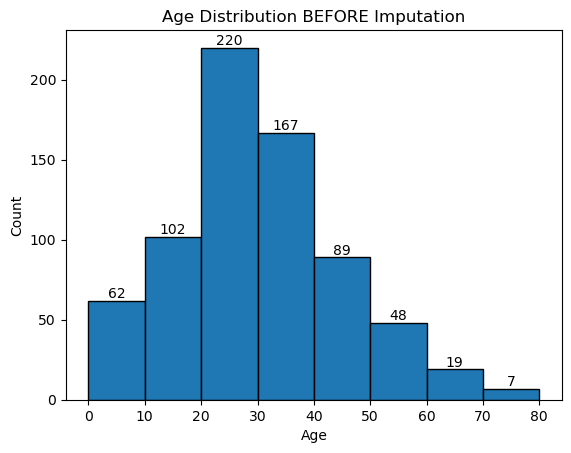

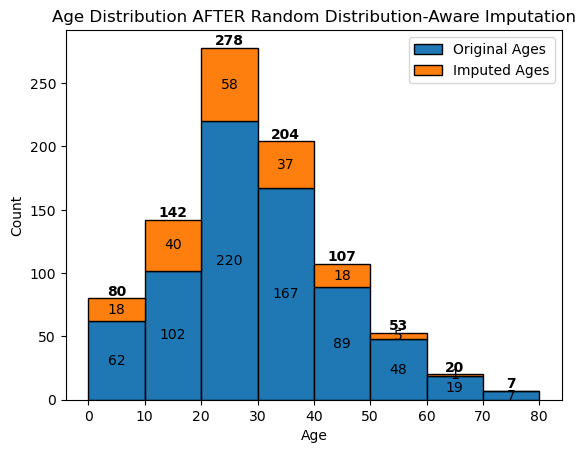

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ==============================================================
# Configuration
# ==============================================================

bins = np.arange(0, 81, 10)
bin_centers = (bins[:-1] + bins[1:]) / 2
AGE_MIN, AGE_MAX = 0, 80


# ==============================================================
# 1. Compute class-wise statistics
# ==============================================================

stats = (
    df
    .dropna(subset=['Age'])
    .groupby('Pclass')['Age']
    .agg(['median', 'std', 'count'])
)

print("\nAge statistics per Pclass:")
print(stats)

medians_equal = stats['median'].std() < 1e-6
stds_equal = stats['std'].std() < 1e-6

print("\nMedians equal across classes:", medians_equal)
print("Standard deviations equal across classes:", stds_equal)


# ==============================================================
# 2. Create mask for missing ages
# ==============================================================

missing_mask = df['Age'].isna()


# ==============================================================
# 3. RANDOM, DISTRIBUTION-AWARE IMPUTATION
# ==============================================================

df_imputed = df.copy()

if medians_equal and stds_equal:
    # --- Global distribution ---
    global_median = stats['median'].mean()
    global_std = stats['std'].mean()

    n_missing = missing_mask.sum()

    sampled_ages = np.random.normal(
        loc=global_median,
        scale=global_std,
        size=n_missing
    )

    df_imputed.loc[missing_mask, 'Age'] = np.clip(
        sampled_ages, AGE_MIN, AGE_MAX
    )

else:
    # --- Class-specific distributions ---
    for pclass, group in stats.iterrows():
        class_mask = (df['Pclass'] == pclass) & missing_mask
        n_missing = class_mask.sum()

        if n_missing == 0:
            continue

        sampled_ages = np.random.normal(
            loc=group['median'],
            scale=group['std'],
            size=n_missing
        )

        df_imputed.loc[class_mask, 'Age'] = np.clip(
            sampled_ages, AGE_MIN, AGE_MAX
        )


# ==============================================================
# 4. Validation
# ==============================================================

print("\nMissing values AFTER imputation:")
print(df_imputed['Age'].isna().sum())

assert df_imputed['Age'].isna().sum() == 0, "❌ Still missing Age values!"


# ==============================================================
# 5. BEFORE histogram (blue only)
# ==============================================================

plt.figure()

counts_before, _, _ = plt.hist(
    df['Age'].dropna(),
    bins=bins,
    edgecolor='black'
)

for c, center in zip(counts_before, bin_centers):
    if c > 0:
        plt.text(center, c, int(c), ha='center', va='bottom')

plt.title('Age Distribution BEFORE Imputation')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(bins)
plt.show()


# ==============================================================
# 6. AFTER histogram with BLUE / ORANGE + TOTAL COUNTS
# ==============================================================

original_ages = df.loc[~missing_mask, 'Age']
imputed_ages = df_imputed.loc[missing_mask, 'Age']

counts_blue, _ = np.histogram(original_ages, bins=bins)
counts_orange, _ = np.histogram(imputed_ages, bins=bins)
counts_total = counts_blue + counts_orange

plt.figure()

# Blue
plt.bar(
    bin_centers,
    counts_blue,
    width=10,
    edgecolor='black',
    label='Original Ages'
)

# Orange
plt.bar(
    bin_centers,
    counts_orange,
    width=10,
    bottom=counts_blue,
    edgecolor='black',
    label='Imputed Ages'
)

# Annotations
for center, blue, orange, total in zip(
    bin_centers, counts_blue, counts_orange, counts_total
):
    if blue > 0:
        plt.text(center, blue / 2, int(blue), ha='center', va='center')
    if orange > 0:
        plt.text(center, blue + orange / 2, int(orange), ha='center', va='center')
    if total > 0:
        plt.text(center, total, int(total), ha='center', va='bottom', fontweight='bold')

plt.title('Age Distribution AFTER Random Distribution-Aware Imputation')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(bins)
plt.legend()
plt.show()


### Feature engineering

In [ ]:
df_features = df_imputed[["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]] # Remove irrelavant columns or undocumented ones
df_features = pd.get_dummies(df_features, columns=["Sex", "Pclass"], dtype=int) # turn Sex and Pclass into categorical one hot columns
df_features["TotalFamily"] = df_features["SibSp"] + df_features["Parch"] # Feature engineer the relation between number of siblings, spouses, children and parents
df_features["IsMinor"] = (df_features["Age"] < 18.0).astype(int) # Add whether someone is a minor or not as a boolean variable
print(df_features)

     Survived        Age  SibSp  Parch     Fare  Sex_female  Sex_male  \
0           0  22.000000      1      0   7.2500           0         1   
1           1  38.000000      1      0  71.2833           1         0   
2           1  26.000000      0      0   7.9250           1         0   
3           1  35.000000      1      0  53.1000           1         0   
4           0  35.000000      0      0   8.0500           0         1   
..        ...        ...    ...    ...      ...         ...       ...   
886         0  27.000000      0      0  13.0000           0         1   
887         1  19.000000      0      0  30.0000           1         0   
888         0  24.162464      1      2  23.4500           1         0   
889         1  26.000000      0      0  30.0000           0         1   
890         0  32.000000      0      0   7.7500           0         1   

     Pclass_1  Pclass_2  Pclass_3  TotalFamily  IsMinor  
0           0         0         1            1        0  
1      

### Train regression

In [ ]:
# Select feature columns (everything except the target)
feature_cols = [c for c in df_features.columns if c != "Survived"]
print("Features:", feature_cols)

X = df_features[feature_cols]
y = df_features["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=y
)

print(f"\nTrain size : {len(X_train)} rows")
print(f"Test size  : {len(X_test)} rows")

model = LogisticRegression(max_iter=1000, random_state=12345)
model.fit(X_train, y_train)

print("Model training complete.")